## Gesture Recognition Case Study

In [1]:
import numpy as np
import os
from skimage.transform import resize
from skimage.io import imread
import datetime
import warnings
warnings.filterwarnings("ignore")

In [2]:
np.random.seed(30)
import random as rn
rn.seed(30)
import tensorflow as tf
import keras
from keras import backend as K
tf.random.set_seed(30)
import matplotlib.pyplot as plt

In [3]:
# Train doc
train_doc = np.random.permutation(open('C:/Atanu/DataScience/Gesture_Recognization/Project_data/train.csv').readlines())

# Validation doc
val_doc = np.random.permutation(open('C:/Atanu/DataScience/Gesture_Recognization/Project_data/val.csv').readlines())

#### Generator

In [5]:
def generator(source_path, folder_list, batch_size, img_idx, height, width):
    print( 'Source path = ', source_path, '& batch size =', batch_size)
    
    len_idx = len(img_idx)
    print('Index Length:', len_idx)
    
    while True:
        t = np.random.permutation(folder_list)

        # Calculate the number of batches
        num_batches = len(t) // batch_size 
        
        # We iterate over the number of batches
        for batch in range(num_batches):
            # x is the number of images you use for each video, (y,z) is the final size of the input images and 3 is the number of channels RGB
            batch_data = np.zeros((batch_size, len_idx, height, width, 3)) 
            # batch_labels is the one hot representation of the output
            batch_labels = np.zeros((batch_size,5)) 

            # Iterate over the batch_size
            for folder in range(batch_size): 
                
                # Read all the images in the folder
                imgs = os.listdir(source_path+'/'+ t[folder + (batch*batch_size)].split(';')[0]) 
                
                # Iterate iver the frames/images of a folder to read them in
                for idx,item in enumerate(img_idx): 
                    image = imread(source_path+'/'+ t[folder + (batch*batch_size)].strip().split(';')[0]+'/'+imgs[item]).astype(np.float32)
                    
                    # Crop the images and resize them. Note that the images are of 2 different shape.
                    if image.shape[1] == 160:
                        image = resize(image[:,20:140,:],(height,width)).astype(np.float32)
                    else:
                        image = resize(image,(height,width)).astype(np.float32)  
                    
                    # And the conv3D will throw error if the inputs in a batch have different shapes
                    # Normalise and feed in the image
                    batch_data[folder,idx,:,:,0] = (image[:,:,0])/255
                    batch_data[folder,idx,:,:,1] = (image[:,:,1])/255
                    batch_data[folder,idx,:,:,2] = (image[:,:,2])/255
                    
                batch_labels[folder, int(t[folder + (batch*batch_size)].strip().split(';')[2])] = 1

            # Yield the batch_data and the batch_labels, remember what does yield do
            yield batch_data, batch_labels

        
        # Write the code for the remaining data points which are left after full batches
        if len(t) % batch_size != 0:
            batch_data = np.zeros((batch_size, len_idx, height, width, 3))
            
            # Batch_labels is the one hot representation of the output
            batch_labels = np.zeros((batch_size, 5)) 
            
            # Iterate over the batch_size
            for folder in range(batch_size):
                
                # Read all the images in the folder
                imgs = os.listdir(source_path+'/'+ t[folder + (batch*batch_size)].split(';')[0])

                # Iterate iver the frames/images of a folder to read them in
                for idx,item in enumerate(img_idx): 
                    image = imread(source_path+'/'+ t[folder + (batch*batch_size)].strip().split(';')[0]+'/'+imgs[item]).astype(np.float32)

                    # Crop the images and resize them. Note that the images are of 2 different shape.
                    if image.shape[1] == 160:
                        image = resize(image[:,20:140,:],(height, width)).astype(np.float32)
                    else:
                        image = resize(image,(height, width)).astype(np.float32) 

                    # Perform normalization on images
                    batch_data[folder,idx,:,:,0] = (image[:,:,0])/255
                    batch_data[folder,idx,:,:,1] = (image[:,:,1])/255
                    batch_data[folder,idx,:,:,2] = (image[:,:,2])/255
                
                batch_labels[folder, int(t[folder + (batch*batch_size)].strip().split(';')[2])] = 1 
            
            yield batch_data, batch_labels

In [6]:
# Folder paths
train_path = 'C:/Atanu/DataScience/Gesture_Recognization/Project_data/train'
val_path = 'C:/Atanu/DataScience/Gesture_Recognization/Project_data/val'

# Total number of train sequence
num_train_sequences = len(train_doc)
print('# training sequences =', num_train_sequences)

# Total number of validation sequence
num_val_sequences = len(val_doc)
print('# validation sequences =', num_val_sequences)

# training sequences = 663
# validation sequences = 100


### Model
Here you make the model using different functionalities that Keras provides. Remember to use `Conv3D` and `MaxPooling3D` and not `Conv2D` and `Maxpooling2D` for a 3D convolution model. You would want to use `TimeDistributed` while building a Conv2D + RNN model. Also remember that the last layer is the softmax. Design the network in such a way that the model is able to give good accuracy on the least number of parameters so that it can fit in the memory of the webcam.

In [8]:
# Import Keras libraries
from keras.models import Sequential, Model
from keras.layers import Dense, GRU, Flatten, TimeDistributed, Flatten, BatchNormalization, Activation
from keras.layers import Conv3D, MaxPooling3D
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras import optimizers
from keras.layers import Dropout

##### Model Creation

In [10]:
def createModel(conv_filters = (32, 64, 128), dense_nodes=(128, 64), dropout= 0.25, num_images = 20, height = 80, width = 80): 
    # Number of softmax classes
    num_classes = 5
    
    model = Sequential()
    
    model.add(Conv3D(conv_filters[0], (3, 3, 3), padding='same', input_shape = (num_images, height, width, 3)))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling3D(pool_size=(2, 2, 2)))
    
    model.add(Conv3D(conv_filters[1], (2, 2, 2), padding='same'))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling3D(pool_size=(2, 2, 2)))
    
    model.add(Conv3D(conv_filters[2], (2, 2, 2), padding='same'))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling3D(pool_size=(2, 2, 2)))
    
    model.add(Flatten())
    model.add(Dense(dense_nodes[0], activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    
    model.add(Dense(dense_nodes[1], activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout))
    
    model.add(Dense(num_classes, activation='softmax'))

    # Optimizer
    optimiser = 'sgd'
    model.compile(optimizer = optimiser, loss = 'categorical_crossentropy', metrics = ['categorical_accuracy'])
    print (model.summary())

    return model

In [11]:
def model_callbacks(filePath, curr_dt_time):

    model_name = 'model_init' + '_' + str(curr_dt_time).replace(' ','').replace(':','_') + '/'
        
    if not os.path.exists(model_name):
        os.mkdir(model_name)
            
    filePath = model_name + 'model-{epoch:05d}-{loss:.5f}-{categorical_accuracy:.5f}-{val_loss:.5f}-{val_categorical_accuracy:.5f}.weights.h5'
    checkpoint = ModelCheckpoint(filePath, monitor = 'val_loss', verbose = 1, save_best_only = False, 
                                 save_weights_only = True, mode = 'auto', save_freq = 'epoch')
    LR = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.2, verbose = 1, patience = 4)
    callbacks_list = [checkpoint, LR]
    return callbacks_list

The `steps_per_epoch` and `validation_steps` are used by `fit_generator` to decide the number of next() calls it need to make.

In [13]:
def calculate_steps(num_train_sequences, num_val_sequences, batch_size):
    if (num_train_sequences % batch_size) == 0:
        steps_per_epoch = int(num_train_sequences / batch_size)
    else:
        steps_per_epoch = (num_train_sequences // batch_size) + 1
    
    if (num_val_sequences % batch_size) == 0:
        validation_steps = int(num_val_sequences/batch_size)
    else:
        validation_steps = (num_val_sequences // batch_size) + 1
        
    return steps_per_epoch, validation_steps

### Model-1

In [24]:
print('Model-1')

# Batch size
batch_size = 20
print ('# Batch size:', batch_size)

# Choose the number of epochs
num_epochs = 20 
print ('# Epochs:', num_epochs)

# Current date time
curr_dt_time = datetime.datetime.now()
print('# Current date tine:', curr_dt_time)

#Number of Images
frame_nums = 12
print('Number of Frames:', frame_nums)

# Image Indexes
img_idx = range(2, 25, 2)
print('Number of Images:', list(img_idx))

height = 80
width = 80
print('Image Resolution: {0} x {1}'.format(height, width))

Model-1
# Batch size: 20
# Epochs: 20
# Current date tine: 2025-01-12 16:08:52.605100
Number of Frames: 12
Number of Images: [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24]
Image Resolution: 80 x 80


In [17]:
# Create model-1

model1 = createModel(num_images = frame_nums, height = height, width = width)
model1

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 12, 80, 80, 32) │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 12, 80, 80, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12, 80, 80, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 6, 40, 40, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 6, 40, 40, 64)  │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 6, 40, 40, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 6, 40, 40, 64)  │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 3, 20, 20, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 3, 20, 20, 128) │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 3, 20, 20, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 20, 20, 128) │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 1, 10, 10, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,733,509 (6.61 MB)

 Trainable params: 1,732,677 (6.61 MB)

 Non-trainable params: 832 (3.25 KB)

None


<Sequential name=sequential, built=True>

In [18]:
callbacks_list = model_callbacks("model_conv3D_1", curr_dt_time)

steps_per_epoch, validation_steps = calculate_steps(num_train_sequences, num_val_sequences, batch_size)

In [19]:
# Train Generator
train_generator = generator(train_path, train_doc, batch_size, img_idx, height, width)

In [20]:
# Validation Generator
val_generator = generator(val_path, val_doc, batch_size, img_idx, height, width)

In [21]:
history = model1.fit(train_generator, steps_per_epoch=steps_per_epoch, epochs=num_epochs, verbose=1, 
                    callbacks = callbacks_list, validation_data = val_generator, 
                    validation_steps = validation_steps, class_weight=None, initial_epoch=0)

Source path =  C:/Atanu/DataScience/Gesture_Recognization/Project_data/train & batch size = 20
Index Length: 12
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - categorical_accuracy: 0.2873 - loss: 1.9795Source path =  C:/Atanu/DataScience/Gesture_Recognization/Project_data/val & batch size = 20
Index Length: 12

Epoch 1: saving model to model_init_2025-01-1210_55_17.446622/model-00001-1.74988-0.36765-1.69712-0.17000.weights.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step - categorical_accuracy: 0.2896 - loss: 1.9730 - val_categorical_accuracy: 0.1700 - val_loss: 1.6971 - learning_rate: 0.0100
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - categorical_accuracy: 0.5100 - loss: 1.3235
Epoch 2: saving model to model_init_2025-01-1210_55_17.446622/model-00002-1.25919-0.51471-2.37566-0.24000.weights.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 102s 3s/step - categorical_accuracy: 0.5101 - loss: 1.3217 - val_categorical_accuracy: 0.2400 - val_loss: 2.3757 - learning_rate: 0.0100
Epoch 3/20
34/34 ━━━━━━━━━

In [22]:
print("Total Params:", model1.count_params())

Total Params: 1733509


In [36]:
def plot_training_validation_acc_loss(history, num_epochs):
    accuracy = history.history['categorical_accuracy']
    validation_acc = history.history['val_categorical_accuracy']
    
    loss = history.history['loss']
    validation_loss = history.history['val_loss']
    
    epochs_range = range(num_epochs)
    
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, accuracy, label = 'Training Accuracy')
    plt.plot(epochs_range, validation_acc, label = 'Validation Accuracy')
    plt.legend(loc = 'lower right')
    plt.title('Training and Validation Accuracy')
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label = 'Training Loss')
    plt.plot(epochs_range, validation_loss, label = 'Validation Loss')
    plt.legend(loc = 'upper right')
    plt.title('Training and Validation Loss')
    plt.show()

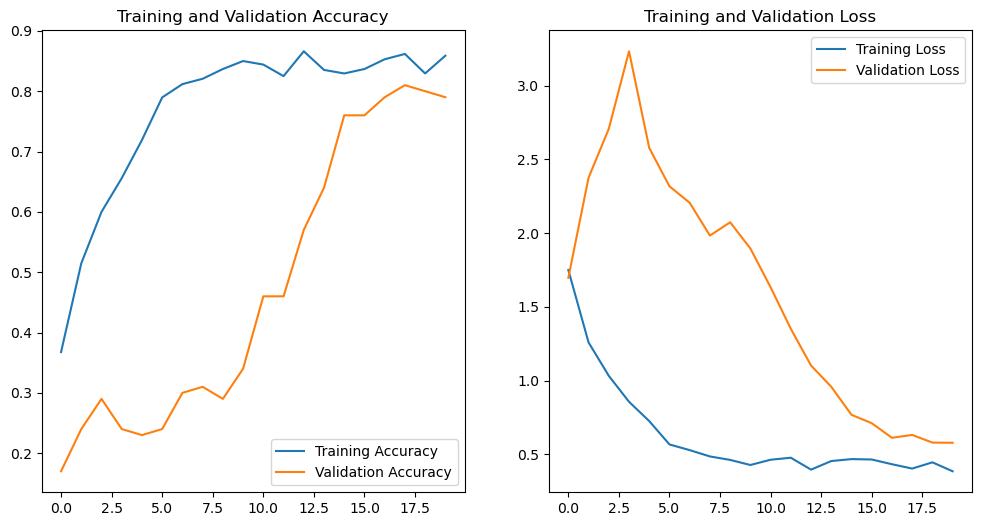

In [24]:
plot_training_validation_acc_loss(history, num_epochs)

### Model-2
Number of frames increased to 20

In [26]:
print('Model-2')

# Batch size
batch_size = 20
print ('# Batch size:', batch_size)

# Choose the number of epochs
num_epochs = 20 
print ('# Epochs:', num_epochs)

# Current date time
curr_dt_time = datetime.datetime.now()
print('# Current date tine:', curr_dt_time)

#Number of Images
frame_nums = 20
print('Number of Frames:', frame_nums)

# Image Indexes
img_idx = [0,2,4,6,8,10,11,12,13,14,15,16,17,18,19,20,22,24,26,28]
print('Number of Images:', img_idx)

height = 80
width = 80
print('Image Resolution: {0} x {1}'.format(height, width))

Model-2
# Batch size: 20
# Epochs: 20
# Current date tine: 2025-01-12 11:28:34.896246
Number of Frames: 20
Number of Images: [0, 2, 4, 6, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 24, 26, 28]
Image Resolution: 80 x 80


In [27]:
# Create model-2

model2 = createModel(num_images = frame_nums, height = height, width = width)
model2

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d_3 (Conv3D)               │ (None, 20, 80, 80, 32) │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 20, 80, 80, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 20, 80, 80, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_3 (MaxPooling3D)  │ (None, 10, 40, 40, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_4 (Conv3D)               │ (None, 10, 40, 40, 64) │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 10, 40, 40, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 10, 40, 40, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_4 (MaxPooling3D)  │ (None, 5, 20, 20, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_5 (Conv3D)               │ (None, 5, 20, 20, 128) │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 5, 20, 20, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 5, 20, 20, 128) │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_5 (MaxPooling3D)  │ (None, 2, 10, 10, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     3,276,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,371,909 (12.86 MB)

 Trainable params: 3,371,077 (12.86 MB)

 Non-trainable params: 832 (3.25 KB)

None


<Sequential name=sequential_1, built=True>

In [28]:
callbacks_list = model_callbacks("model_conv3D_1", curr_dt_time)

steps_per_epoch, validation_steps = calculate_steps(num_train_sequences, num_val_sequences, batch_size)

In [29]:
# Train Generator
train_generator = generator(train_path, train_doc, batch_size, img_idx, height, width)

In [30]:
# Validation Generator
val_generator = generator(val_path, val_doc, batch_size, img_idx, height, width)

In [31]:
history2 = model2.fit(train_generator, steps_per_epoch=steps_per_epoch, epochs=num_epochs, verbose=1, 
                    callbacks = callbacks_list, validation_data = val_generator, 
                    validation_steps = validation_steps, class_weight = None, initial_epoch = 0)

Source path =  C:/Atanu/DataScience/Gesture_Recognization/Project_data/train & batch size = 20
Index Length: 20
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - categorical_accuracy: 0.3859 - loss: 1.7983Source path =  C:/Atanu/DataScience/Gesture_Recognization/Project_data/val & batch size = 20
Index Length: 20

Epoch 1: saving model to model_init_2025-01-1211_28_34.896246/model-00001-1.64610-0.41471-1.80623-0.18000.weights.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 253s 8s/step - categorical_accuracy: 0.3867 - loss: 1.7940 - val_categorical_accuracy: 0.1800 - val_loss: 1.8062 - learning_rate: 0.0100
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - categorical_accuracy: 0.5678 - loss: 1.1304
Epoch 2: saving model to model_init_2025-01-1211_28_34.896246/model-00002-1.05994-0.57941-2.29059-0.21000.weights.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 169s 5s/step - categorical_accuracy: 0.5682 - loss: 1.1284 - val_categorical_accuracy: 0.2100 - val_loss: 2.2906 - learning_rate: 0.0100
Epoch 3/20
34/34 ━━━━━━━━━

In [32]:
print("Total Params:", model2.count_params())

Total Params: 3371909


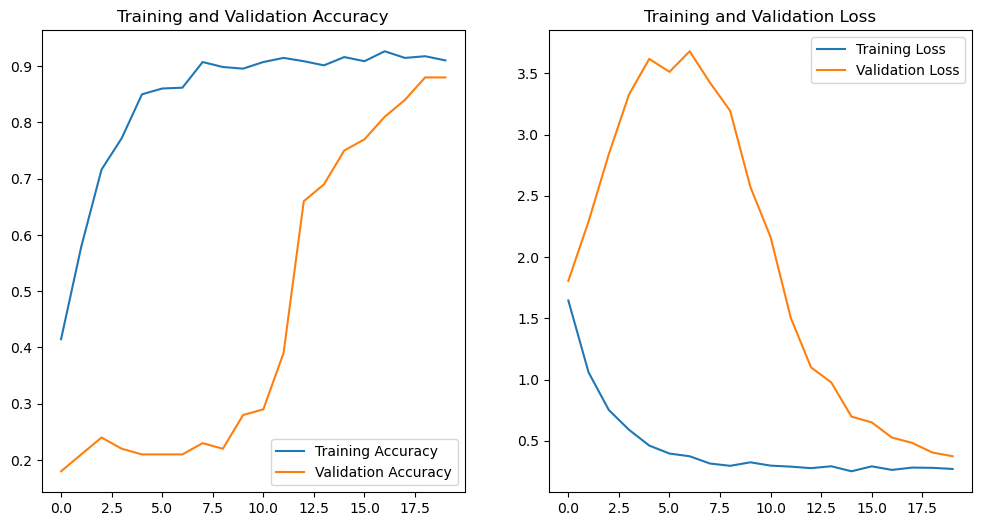

In [33]:
plot_training_validation_acc_loss(history2, num_epochs)

### Model-3
Number of frames increased to 30 

In [35]:
print('Model-3')

# Batch size
batch_size = 20
print ('# Batch size:', batch_size)

# Choose the number of epochs
num_epochs = 20 
print ('# Epochs:', num_epochs)

# Current date time
curr_dt_time = datetime.datetime.now()
print('# Current date tine:', curr_dt_time)

#Number of Images
frame_nums = 30
print('Number of Frames:', frame_nums)

# Image Indexes
img_idx = range(0, 30)
print('Number of Images:', list(img_idx))

height = 80
width = 80
print('Image Resolution: {0} x {1}'.format(height, width))

Model-3
# Batch size: 20
# Epochs: 20
# Current date tine: 2025-01-12 12:25:01.451306
Number of Frames: 30
Number of Images: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
Image Resolution: 80 x 80


In [36]:
# Create model-3

model3 = createModel(num_images = frame_nums, height = height, width = width)
model3

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d_6 (Conv3D)               │ (None, 30, 80, 80, 32) │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 30, 80, 80, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 30, 80, 80, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_6 (MaxPooling3D)  │ (None, 15, 40, 40, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_7 (Conv3D)               │ (None, 15, 40, 40, 64) │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 15, 40, 40, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 15, 40, 40, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_7 (MaxPooling3D)  │ (None, 7, 20, 20, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_8 (Conv3D)               │ (None, 7, 20, 20, 128) │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 7, 20, 20, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 7, 20, 20, 128) │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_8 (MaxPooling3D)  │ (None, 3, 10, 10, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 38400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     4,915,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,010,309 (19.11 MB)

 Trainable params: 5,009,477 (19.11 MB)

 Non-trainable params: 832 (3.25 KB)

None


<Sequential name=sequential_2, built=True>

In [37]:
callbacks_list = model_callbacks("model_conv3D_1", curr_dt_time)

steps_per_epoch, validation_steps = calculate_steps(num_train_sequences, num_val_sequences, batch_size)

In [38]:
# Train Generator
train_generator = generator(train_path, train_doc, batch_size, img_idx, height, width)

In [39]:
# Validation Generator
val_generator = generator(val_path, val_doc, batch_size, img_idx, height, width)

In [40]:
history3 = model3.fit(train_generator, steps_per_epoch=steps_per_epoch, epochs=num_epochs, verbose=1, 
                    callbacks = callbacks_list, validation_data = val_generator, 
                    validation_steps = validation_steps, class_weight = None, initial_epoch = 0)

Source path =  C:/Atanu/DataScience/Gesture_Recognization/Project_data/train & batch size = 20
Index Length: 30
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - categorical_accuracy: 0.3601 - loss: 1.8792 Source path =  C:/Atanu/DataScience/Gesture_Recognization/Project_data/val & batch size = 20
Index Length: 30

Epoch 1: saving model to model_init_2025-01-1212_25_01.451306/model-00001-1.62863-0.42647-1.57089-0.29000.weights.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 512s 15s/step - categorical_accuracy: 0.3620 - loss: 1.8720 - val_categorical_accuracy: 0.2900 - val_loss: 1.5709 - learning_rate: 0.0100
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - categorical_accuracy: 0.5267 - loss: 1.1206
Epoch 2: saving model to model_init_2025-01-1212_25_01.451306/model-00002-1.07766-0.55147-3.02989-0.26000.weights.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 277s 8s/step - categorical_accuracy: 0.5274 - loss: 1.1193 - val_categorical_accuracy: 0.2600 - val_loss: 3.0299 - learning_rate: 0.0100
Epoch 3/20
34/34 ━━━━━━

In [41]:
print("Total Params:", model3.count_params())

Total Params: 5010309


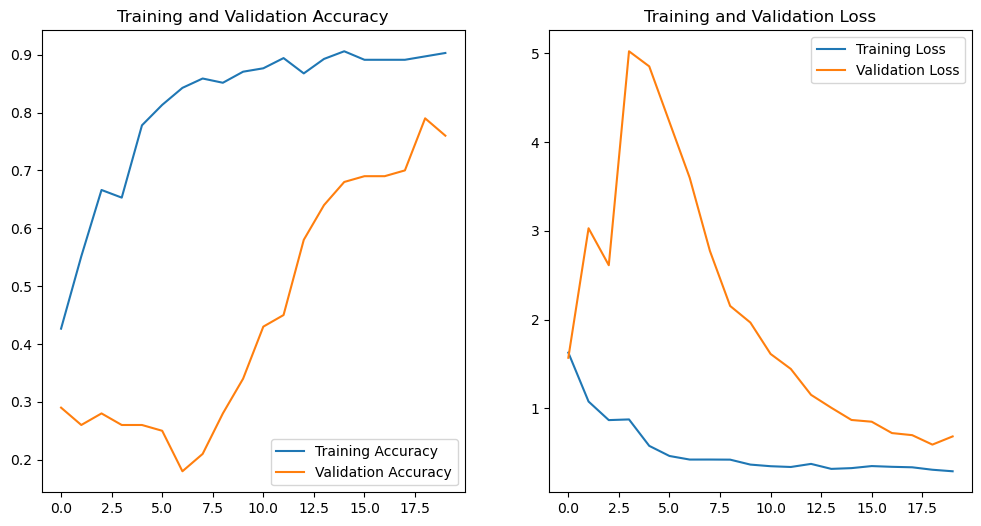

In [42]:
plot_training_validation_acc_loss(history3, num_epochs)

### Model-4
Batch size increased to 32 and number of frames reduced to 20 with specified index. Image resolution increased to 120x120. 

In [26]:
print('Model-4')

# Batch size
batch_size = 32
print ('# Batch size:', batch_size)

# Choose the number of epochs
num_epochs = 20 
print ('# Epochs:', num_epochs)

# Current date time
curr_dt_time = datetime.datetime.now()
print('# Current date tine:', curr_dt_time)

#Number of Images
frame_nums = 20
print('# Number of Frames:', frame_nums)

# Image Indexes
img_idx = [0,2,4,6,8,10,11,12,13,14,15,16,17,18,19,20,22,24,26,28]
print('# Number of Images:', img_idx)

height = 120
width = 120
print('# Image Resolution: {0} x {1}'.format(height, width))

Model-4
# Batch size: 32
# Epochs: 20
# Current date tine: 2025-01-12 16:10:03.677155
# Number of Frames: 20
# Number of Images: [0, 2, 4, 6, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 24, 26, 28]
# Image Resolution: 120 x 120


In [28]:
# Create model-4

model4 = createModel(num_images = frame_nums, height = height, width = width)
model4

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 20, 120, 120,   │         2,624 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 20, 120, 120,   │             0 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 120, 120,   │           128 │
│ (BatchNormalization)            │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 10, 60, 60, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 10, 60, 60, 64) │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 10, 60, 60, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 60, 60, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 5, 30, 30, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 5, 30, 30, 128) │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 5, 30, 30, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 5, 30, 30, 128) │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 2, 15, 15, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,467,909 (28.49 MB)

 Trainable params: 7,467,077 (28.48 MB)

 Non-trainable params: 832 (3.25 KB)

None


<Sequential name=sequential, built=True>

In [30]:
callbacks_list = model_callbacks("model_conv3D_1", curr_dt_time)

steps_per_epoch, validation_steps = calculate_steps(num_train_sequences, num_val_sequences, batch_size)

In [32]:
# Train Generator
train_generator = generator(train_path, train_doc, batch_size, img_idx, height, width)

In [34]:
# Validation Generator
val_generator = generator(val_path, val_doc, batch_size, img_idx, height, width)

In [36]:
history4 = model4.fit(train_generator, steps_per_epoch=steps_per_epoch, epochs=num_epochs, verbose=1, 
                    callbacks = callbacks_list, validation_data = val_generator, 
                    validation_steps = validation_steps, class_weight = None, initial_epoch = 0)

Source path =  C:/Atanu/DataScience/Gesture_Recognization/Project_data/train & batch size = 32
Index Length: 20
Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - categorical_accuracy: 0.3566 - loss: 1.6947 Source path =  C:/Atanu/DataScience/Gesture_Recognization/Project_data/val & batch size = 32
Index Length: 20

Epoch 1: saving model to model_init_2025-01-1216_10_03.677155/model-00001-1.47543-0.44048-1.60404-0.20312.weights.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 398s 19s/step - categorical_accuracy: 0.3604 - loss: 1.6848 - val_categorical_accuracy: 0.2031 - val_loss: 1.6040 - learning_rate: 0.0100
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - categorical_accuracy: 0.5776 - loss: 1.0454 
Epoch 2: saving model to model_init_2025-01-1216_10_03.677155/model-00002-0.95278-0.62202-1.67904-0.21094.weights.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 257s 13s/step - categorical_accuracy: 0.5797 - loss: 1.0412 - val_categorical_accuracy: 0.2109 - val_loss: 1.6790 - learning_rate: 0.0100
Epoch 3/20
21/21 ━━━

In [37]:
print("Total Params:", model4.count_params())

Total Params: 7467909


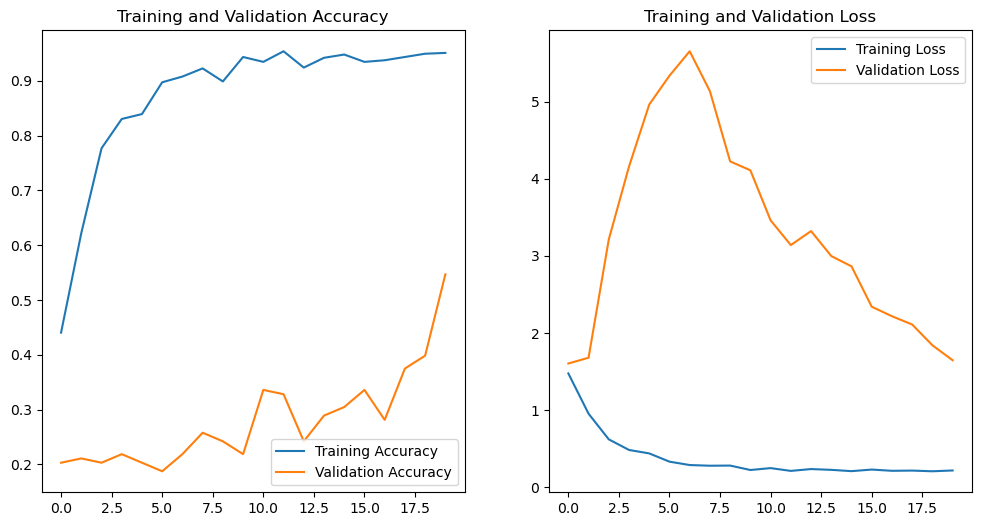

In [49]:
plot_training_validation_acc_loss(history4, num_epochs)

### Model-5
Number of epocs reduced to 10

In [23]:
print('Model-5')

# Batch size
batch_size = 32
print ('# Batch size:', batch_size)

# Choose the number of epochs
num_epochs = 10 
print ('# Epochs:', num_epochs)

# Current date time
curr_dt_time = datetime.datetime.now()
print('# Current date tine:', curr_dt_time)

#Number of Images
frame_nums = 20
print('# Number of Frames:', frame_nums)

# Image Indexes
img_idx = [0,2,4,6,8,10,11,12,13,14,15,16,17,18,19,20,22,24,26,28]
print('# Number of Images:', img_idx)

height = 120
width = 120
print('# Image Resolution: {0} x {1}'.format(height, width))

Model-5
# Batch size: 32
# Epochs: 10
# Current date tine: 2025-01-12 21:52:12.737074
# Number of Frames: 20
# Number of Images: [0, 2, 4, 6, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 24, 26, 28]
# Image Resolution: 120 x 120


In [25]:
# Create model-5

model5 = createModel(num_images = frame_nums, height = height, width = width)
model5

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 20, 120, 120,   │         2,624 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 20, 120, 120,   │             0 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 120, 120,   │           128 │
│ (BatchNormalization)            │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 10, 60, 60, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 10, 60, 60, 64) │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 10, 60, 60, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 60, 60, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 5, 30, 30, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 5, 30, 30, 128) │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 5, 30, 30, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 5, 30, 30, 128) │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 2, 15, 15, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,467,909 (28.49 MB)

 Trainable params: 7,467,077 (28.48 MB)

 Non-trainable params: 832 (3.25 KB)

None


<Sequential name=sequential, built=True>

In [26]:
callbacks_list = model_callbacks("model_conv3D_1", curr_dt_time)

steps_per_epoch, validation_steps = calculate_steps(num_train_sequences, num_val_sequences, batch_size)

In [27]:
# Train Generator
train_generator = generator(train_path, train_doc, batch_size, img_idx, height, width)

In [30]:
# Validation Generator
val_generator = generator(val_path, val_doc, batch_size, img_idx, height, width)

In [33]:
history5 = model5.fit(train_generator, steps_per_epoch=steps_per_epoch, epochs=num_epochs, verbose=1, 
                    callbacks = callbacks_list, validation_data = val_generator, 
                    validation_steps = validation_steps, class_weight = None, initial_epoch = 0)

Source path =  C:/Atanu/DataScience/Gesture_Recognization/Project_data/train & batch size = 32
Index Length: 20
Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 24s/step - categorical_accuracy: 0.3566 - loss: 1.6947 Source path =  C:/Atanu/DataScience/Gesture_Recognization/Project_data/val & batch size = 32
Index Length: 20

Epoch 1: saving model to model_init_2025-01-1221_52_12.737074/model-00001-1.47543-0.44048-1.60404-0.20312.weights.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 570s 28s/step - categorical_accuracy: 0.3604 - loss: 1.6848 - val_categorical_accuracy: 0.2031 - val_loss: 1.6040 - learning_rate: 0.0100
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 83s/step - categorical_accuracy: 0.5776 - loss: 1.0454  
Epoch 2: saving model to model_init_2025-01-1221_52_12.737074/model-00002-0.95278-0.62202-1.67904-0.21094.weights.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 1698s 85s/step - categorical_accuracy: 0.5797 - loss: 1.0412 - val_categorical_accuracy: 0.2109 - val_loss: 1.6790 - learning_rate: 0.0100
Epoch 3/10
21/21 ━

In [34]:
print("Total Params:", model5.count_params())

Total Params: 7467909


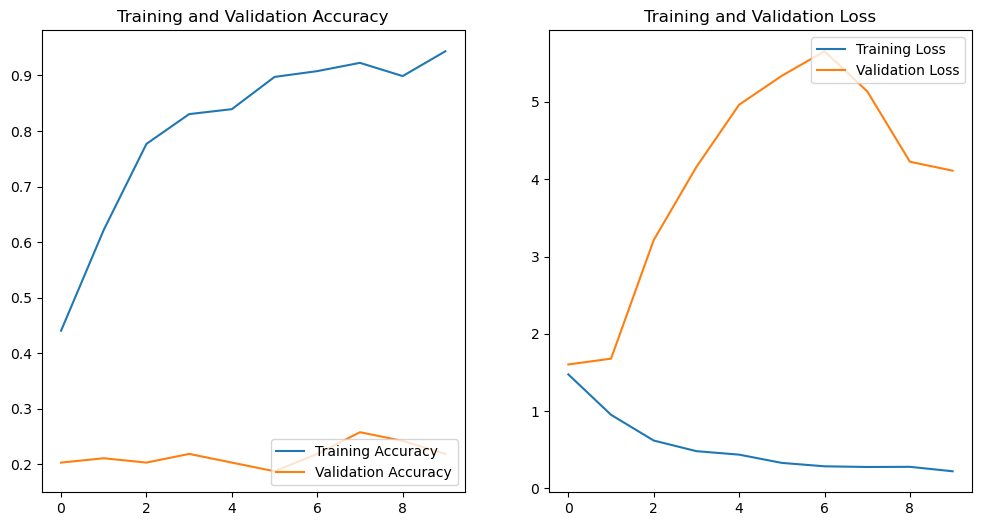

In [38]:
plot_training_validation_acc_loss(history5, num_epochs)

### Model-6
Number of epocs increased to 40

In [46]:
print('Model-6')

# Batch size
batch_size = 32
print ('# Batch size:', batch_size)

# Choose the number of epochs
num_epochs = 40 
print ('# Epochs:', num_epochs)

# Current date time
curr_dt_time = datetime.datetime.now()
print('# Current date tine:', curr_dt_time)

#Number of Images
frame_nums = 20
print('# Number of Frames:', frame_nums)

# Image Indexes
img_idx = [0,2,4,6,8,10,11,12,13,14,15,16,17,18,19,20,22,24,26,28]
print('# Number of Images:', img_idx)

height = 120
width = 120
print('# Image Resolution: {0} x {1}'.format(height, width))

Model-6
# Batch size: 32
# Epochs: 40
# Current date tine: 2025-01-12 23:17:21.314121
# Number of Frames: 20
# Number of Images: [0, 2, 4, 6, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 24, 26, 28]
# Image Resolution: 120 x 120


In [48]:
# Create model-6

model6 = createModel(num_images = frame_nums, height = height, width = width)
model6

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d_3 (Conv3D)               │ (None, 20, 120, 120,   │         2,624 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 20, 120, 120,   │             0 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 20, 120, 120,   │           128 │
│ (BatchNormalization)            │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_3 (MaxPooling3D)  │ (None, 10, 60, 60, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_4 (Conv3D)               │ (None, 10, 60, 60, 64) │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 10, 60, 60, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 10, 60, 60, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_4 (MaxPooling3D)  │ (None, 5, 30, 30, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_5 (Conv3D)               │ (None, 5, 30, 30, 128) │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 5, 30, 30, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 5, 30, 30, 128) │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_5 (MaxPooling3D)  │ (None, 2, 15, 15, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,467,909 (28.49 MB)

 Trainable params: 7,467,077 (28.48 MB)

 Non-trainable params: 832 (3.25 KB)

None


<Sequential name=sequential_1, built=True>

In [50]:
callbacks_list = model_callbacks("model_conv3D_1", curr_dt_time)

steps_per_epoch, validation_steps = calculate_steps(num_train_sequences, num_val_sequences, batch_size)

In [52]:
# Train Generator
train_generator = generator(train_path, train_doc, batch_size, img_idx, height, width)

In [54]:
# Validation Generator
val_generator = generator(val_path, val_doc, batch_size, img_idx, height, width)

In [56]:
history6 = model6.fit(train_generator, steps_per_epoch=steps_per_epoch, epochs=num_epochs, verbose=1, 
                    callbacks = callbacks_list, validation_data = val_generator, 
                    validation_steps = validation_steps, class_weight = None, initial_epoch = 0)

Source path =  C:/Atanu/DataScience/Gesture_Recognization/Project_data/train & batch size = 32
Index Length: 20
Epoch 1/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - categorical_accuracy: 0.3272 - loss: 1.8783 Source path =  C:/Atanu/DataScience/Gesture_Recognization/Project_data/val & batch size = 32
Index Length: 20

Epoch 1: saving model to model_init_2025-01-1223_17_21.314121/model-00001-1.49959-0.44940-1.89002-0.23438.weights.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 325s 16s/step - categorical_accuracy: 0.3328 - loss: 1.8611 - val_categorical_accuracy: 0.2344 - val_loss: 1.8900 - learning_rate: 0.0100
Epoch 2/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - categorical_accuracy: 0.6530 - loss: 0.8936 
Epoch 2: saving model to model_init_2025-01-1223_17_21.314121/model-00002-0.91886-0.64732-2.94288-0.21094.weights.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 328s 16s/step - categorical_accuracy: 0.6527 - loss: 0.8947 - val_categorical_accuracy: 0.2109 - val_loss: 2.9429 - learning_rate: 0.0100
Epoch 3/40
21/21 ━━━

In [59]:
print("Total Params:", model6.count_params())

Total Params: 7467909


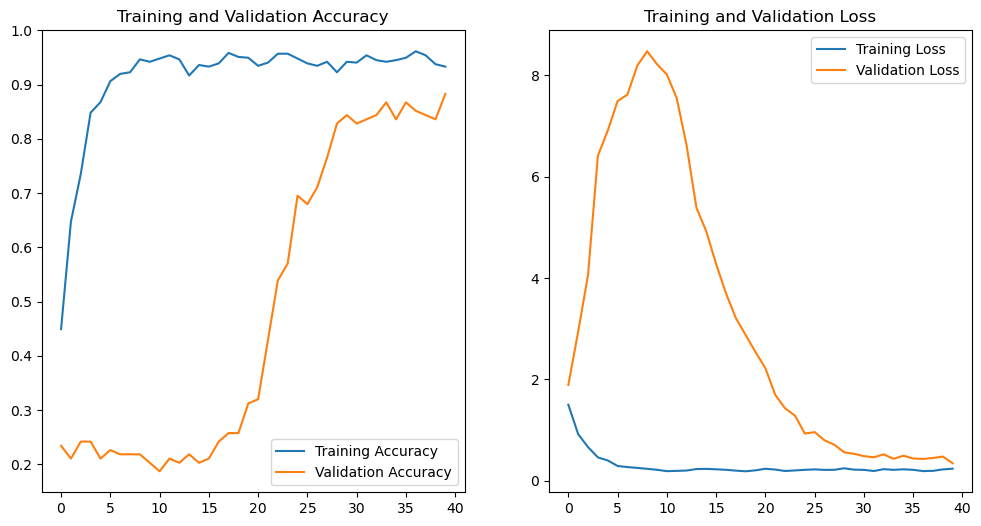

In [60]:
plot_training_validation_acc_loss(history6, num_epochs)

### Model-7
CNN + LSTM

In [63]:
print('Model-7')

# Batch size
batch_size = 20
print ('# Batch size:', batch_size)

# Choose the number of epochs
num_epochs = 20 
print ('# Epochs:', num_epochs)

# Current date time
curr_dt_time = datetime.datetime.now()
print('# Current date tine:', curr_dt_time)

#Number of Images
frame_nums = 20
print('# Number of Frames:', frame_nums)

# Image Indexes
img_idx = [0,2,4,6,8,10,11,12,13,14,15,16,17,18,19,20,22,24,26,28]
print('# Number of Images:', img_idx)

height = 120
width = 120
print('# Image Resolution: {0} x {1}'.format(height, width))

Model-7
# Batch size: 20
# Epochs: 20
# Current date tine: 2025-01-13 02:08:39.272581
# Number of Frames: 20
# Number of Images: [0, 2, 4, 6, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 24, 26, 28]
# Image Resolution: 120 x 120


In [69]:
from keras.layers import LSTM

def createLstmModel(conv_filters = (32, 64, 128), dense_nodes=(128, 64), dropout= 0.25, num_images = 20, height = 80, width = 80): 
    # Number of softmax classes
    num_classes = 5
    
    model = Sequential()
    
    model.add(Conv3D(conv_filters[0], (3, 3, 3), padding='same', input_shape = (num_images, height, width, 3)))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling3D(pool_size=(2, 2, 2)))
    
    model.add(Conv3D(conv_filters[1], (2, 2, 2), padding='same'))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling3D(pool_size=(2, 2, 2)))
    
    model.add(Conv3D(conv_filters[2], (2, 2, 2), padding='same'))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling3D(pool_size=(2, 2, 2)))
    
    model.add(TimeDistributed(Flatten()))
    model.add(LSTM(dense_nodes[0]))
    model.add(Dropout(0.5))
    
    model.add(Dense(dense_nodes[1], activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout))
    
    model.add(Dense(num_classes, activation='softmax'))

    # Optimizer
    optimiser = 'sgd'
    model.compile(optimizer = optimiser, loss = 'categorical_crossentropy', metrics = ['categorical_accuracy'])
    print (model.summary())

    return model

In [71]:
# Create model-7

model7 = createLstmModel(num_images = frame_nums, height = height, width = width)
model7

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d_6 (Conv3D)               │ (None, 20, 120, 120,   │         2,624 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 20, 120, 120,   │             0 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 20, 120, 120,   │           128 │
│ (BatchNormalization)            │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_6 (MaxPooling3D)  │ (None, 10, 60, 60, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_7 (Conv3D)               │ (None, 10, 60, 60, 64) │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 10, 60, 60, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 10, 60, 60, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_7 (MaxPooling3D)  │ (None, 5, 30, 30, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_8 (Conv3D)               │ (None, 5, 30, 30, 128) │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 5, 30, 30, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 5, 30, 30, 128) │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_8 (MaxPooling3D)  │ (None, 2, 15, 15, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 2, 28800)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │    14,811,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,906,117 (56.86 MB)

 Trainable params: 14,905,541 (56.86 MB)

 Non-trainable params: 576 (2.25 KB)

None


<Sequential name=sequential_2, built=True>

In [73]:
callbacks_list = model_callbacks("model_conv3D_1", curr_dt_time)

steps_per_epoch, validation_steps = calculate_steps(num_train_sequences, num_val_sequences, batch_size)

In [75]:
# Train Generator
train_generator = generator(train_path, train_doc, batch_size, img_idx, height, width)

In [77]:
# Validation Generator
val_generator = generator(val_path, val_doc, batch_size, img_idx, height, width)

In [79]:
history7 = model7.fit(train_generator, steps_per_epoch=steps_per_epoch, epochs=num_epochs, verbose=1, 
                    callbacks = callbacks_list, validation_data = val_generator, 
                    validation_steps = validation_steps, class_weight = None, initial_epoch = 0)

Source path =  C:/Atanu/DataScience/Gesture_Recognization/Project_data/train & batch size = 20
Index Length: 20
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - categorical_accuracy: 0.2439 - loss: 2.1713Source path =  C:/Atanu/DataScience/Gesture_Recognization/Project_data/val & batch size = 20
Index Length: 20

Epoch 1: saving model to model_init_2025-01-1302_08_39.272581/model-00001-2.12289-0.24265-1.62354-0.19000.weights.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 319s 9s/step - categorical_accuracy: 0.2439 - loss: 2.1699 - val_categorical_accuracy: 0.1900 - val_loss: 1.6235 - learning_rate: 0.0100
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - categorical_accuracy: 0.2674 - loss: 1.8659
Epoch 2: saving model to model_init_2025-01-1302_08_39.272581/model-00002-1.77302-0.30588-1.62406-0.24000.weights.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 215s 6s/step - categorical_accuracy: 0.2685 - loss: 1.8632 - val_categorical_accuracy: 0.2400 - val_loss: 1.6241 - learning_rate: 0.0100
Epoch 3/20
34/34 ━━━━━━━━━

In [80]:
print("Total Params:", model7.count_params())

Total Params: 14906117


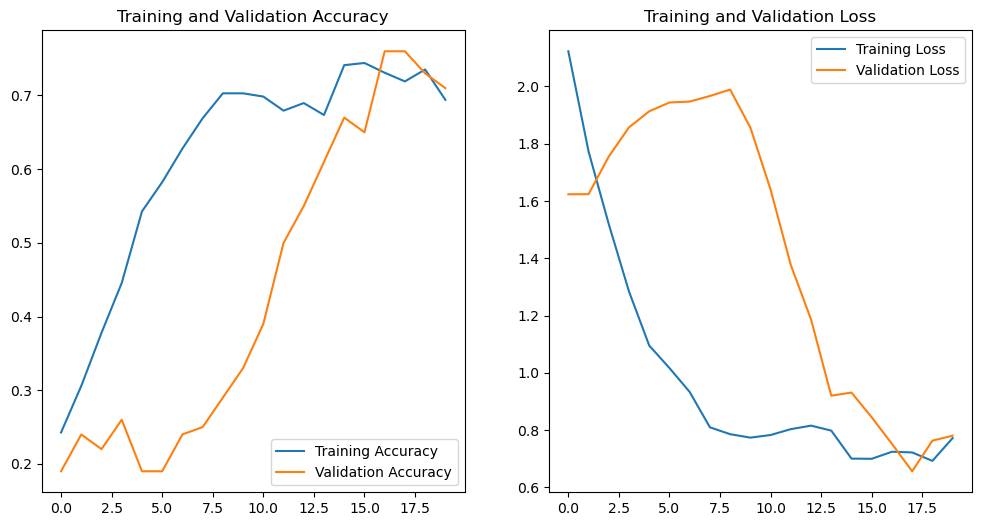

In [81]:
plot_training_validation_acc_loss(history7, num_epochs)

### Model-8
CNN + LSTM, Image size incresed to 160x160

In [126]:
print('Model-8')

# Batch size
batch_size = 20
print ('# Batch size:', batch_size)

# Choose the number of epochs
num_epochs = 20 
print ('# Epochs:', num_epochs)

# Current date time
curr_dt_time = datetime.datetime.now()
print('# Current date tine:', curr_dt_time)

#Number of Images
frame_nums = 20
print('# Number of Frames:', frame_nums)

# Image Indexes
img_idx = [0,2,4,6,8,10,11,12,13,14,15,16,17,18,19,20,22,24,26,28]
print('# Number of Images:', img_idx)

height = 160
width = 160
print('# Image Resolution: {0} x {1}'.format(height, width))

Model-8
# Batch size: 20
# Epochs: 20
# Current date tine: 2025-01-13 14:59:40.922611
# Number of Frames: 20
# Number of Images: [0, 2, 4, 6, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 24, 26, 28]
# Image Resolution: 160 x 160


In [89]:
# Create model-8

model8 = createLstmModel(num_images = frame_nums, height = height, width = width)
model8

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d_9 (Conv3D)               │ (None, 20, 160, 160,   │         2,624 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 20, 160, 160,   │             0 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 20, 160, 160,   │           128 │
│ (BatchNormalization)            │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_9 (MaxPooling3D)  │ (None, 10, 80, 80, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_10 (Conv3D)              │ (None, 10, 80, 80, 64) │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 10, 80, 80, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 10, 80, 80, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_10 (MaxPooling3D) │ (None, 5, 40, 40, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_11 (Conv3D)              │ (None, 5, 40, 40, 128) │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 5, 40, 40, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 5, 40, 40, 128) │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_11 (MaxPooling3D) │ (None, 2, 20, 20, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 2, 51200)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │    26,280,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,374,917 (100.61 MB)

 Trainable params: 26,374,341 (100.61 MB)

 Non-trainable params: 576 (2.25 KB)

None


<Sequential name=sequential_3, built=True>

In [97]:
callbacks_list = model_callbacks("model_conv3D_1", curr_dt_time)

steps_per_epoch, validation_steps = calculate_steps(num_train_sequences, num_val_sequences, batch_size)

In [99]:
# Train Generator
train_generator = generator(train_path, train_doc, batch_size, img_idx, height, width)

In [101]:
# Validation Generator
val_generator = generator(val_path, val_doc, batch_size, img_idx, height, width)

In [103]:
history8 = model8.fit(train_generator, steps_per_epoch=steps_per_epoch, epochs=num_epochs, verbose=1, 
                    callbacks = callbacks_list, validation_data = val_generator, 
                    validation_steps = validation_steps, class_weight = None, initial_epoch = 0)

Source path =  C:/Atanu/DataScience/Gesture_Recognization/Project_data/train & batch size = 20
Index Length: 20
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - categorical_accuracy: 0.2186 - loss: 2.2101 Source path =  C:/Atanu/DataScience/Gesture_Recognization/Project_data/val & batch size = 20
Index Length: 20

Epoch 1: saving model to model_init_2025-01-1312_43_33.683782/model-00001-2.12160-0.22059-1.59069-0.29000.weights.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 771s 22s/step - categorical_accuracy: 0.2187 - loss: 2.2076 - val_categorical_accuracy: 0.2900 - val_loss: 1.5907 - learning_rate: 0.0100
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - categorical_accuracy: 0.2671 - loss: 1.8980 
Epoch 2: saving model to model_init_2025-01-1312_43_33.683782/model-00002-1.80179-0.29559-1.63252-0.13000.weights.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 489s 15s/step - categorical_accuracy: 0.2679 - loss: 1.8953 - val_categorical_accuracy: 0.1300 - val_loss: 1.6325 - learning_rate: 0.0100
Epoch 3/20
34/34 ━━━

In [105]:
print("Total Params:", model8.count_params())

Total Params: 26374917


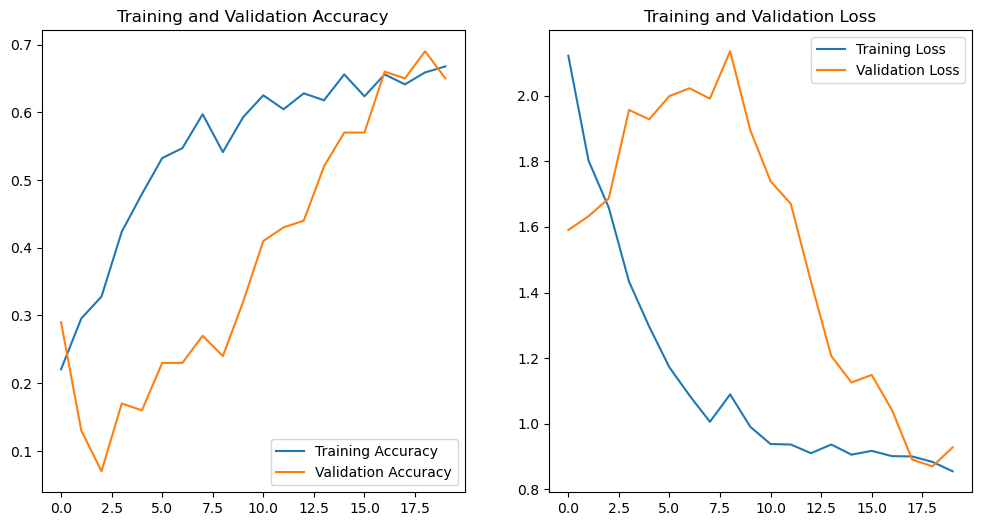

In [107]:
plot_training_validation_acc_loss(history8, num_epochs)

### Model-9
CNN + LSTM, image size reduced back to 120x120. Number of epocs increased to 40.

In [129]:
print('Model-9')

# Batch size
batch_size = 20
print ('# Batch size:', batch_size)

# Choose the number of epochs
num_epochs = 40 
print ('# Epochs:', num_epochs)

# Current date time
curr_dt_time = datetime.datetime.now()
print('# Current date tine:', curr_dt_time)

#Number of Images
frame_nums = 20
print('# Number of Frames:', frame_nums)

# Image Indexes
img_idx = [0,2,4,6,8,10,11,12,13,14,15,16,17,18,19,20,22,24,26,28]
print('# Number of Images:', img_idx)

height = 120
width = 120
print('# Image Resolution: {0} x {1}'.format(height, width))

Model-9
# Batch size: 20
# Epochs: 40
# Current date tine: 2025-01-13 15:00:30.639522
# Number of Frames: 20
# Number of Images: [0, 2, 4, 6, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 24, 26, 28]
# Image Resolution: 120 x 120


In [131]:
# Create model-9

model9 = createLstmModel(num_images = frame_nums, height = height, width = width)
model9

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d_12 (Conv3D)              │ (None, 20, 120, 120,   │         2,624 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 20, 120, 120,   │             0 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 20, 120, 120,   │           128 │
│ (BatchNormalization)            │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_12 (MaxPooling3D) │ (None, 10, 60, 60, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_13 (Conv3D)              │ (None, 10, 60, 60, 64) │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 10, 60, 60, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 10, 60, 60, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_13 (MaxPooling3D) │ (None, 5, 30, 30, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_14 (Conv3D)              │ (None, 5, 30, 30, 128) │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 5, 30, 30, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 5, 30, 30, 128) │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_14 (MaxPooling3D) │ (None, 2, 15, 15, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 2, 28800)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │    14,811,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,906,117 (56.86 MB)

 Trainable params: 14,905,541 (56.86 MB)

 Non-trainable params: 576 (2.25 KB)

None


<Sequential name=sequential_4, built=True>

In [133]:
callbacks_list = model_callbacks("model_conv3D_1", curr_dt_time)

steps_per_epoch, validation_steps = calculate_steps(num_train_sequences, num_val_sequences, batch_size)

In [135]:
# Train Generator
train_generator = generator(train_path, train_doc, batch_size, img_idx, height, width)

In [137]:
# Validation Generator
val_generator = generator(val_path, val_doc, batch_size, img_idx, height, width)

In [139]:
history9 = model9.fit(train_generator, steps_per_epoch=steps_per_epoch, epochs=num_epochs, verbose=1, 
                    callbacks = callbacks_list, validation_data = val_generator, 
                    validation_steps = validation_steps, class_weight = None, initial_epoch = 0)

Source path =  C:/Atanu/DataScience/Gesture_Recognization/Project_data/train & batch size = 20
Index Length: 20
Epoch 1/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - categorical_accuracy: 0.2280 - loss: 2.1491Source path =  C:/Atanu/DataScience/Gesture_Recognization/Project_data/val & batch size = 20
Index Length: 20

Epoch 1: saving model to model_init_2025-01-1315_00_30.639522/model-00001-1.95048-0.25441-1.53640-0.28000.weights.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 246s 7s/step - categorical_accuracy: 0.2288 - loss: 2.1434 - val_categorical_accuracy: 0.2800 - val_loss: 1.5364 - learning_rate: 0.0100
Epoch 2/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - categorical_accuracy: 0.4027 - loss: 1.5980
Epoch 2: saving model to model_init_2025-01-1315_00_30.639522/model-00002-1.65417-0.37500-1.72248-0.18000.weights.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 221s 7s/step - categorical_accuracy: 0.4020 - loss: 1.5996 - val_categorical_accuracy: 0.1800 - val_loss: 1.7225 - learning_rate: 0.0100
Epoch 3/40
34/34 ━━━━━━━━━

In [140]:
print("Total Params:", model9.count_params())

Total Params: 14906117


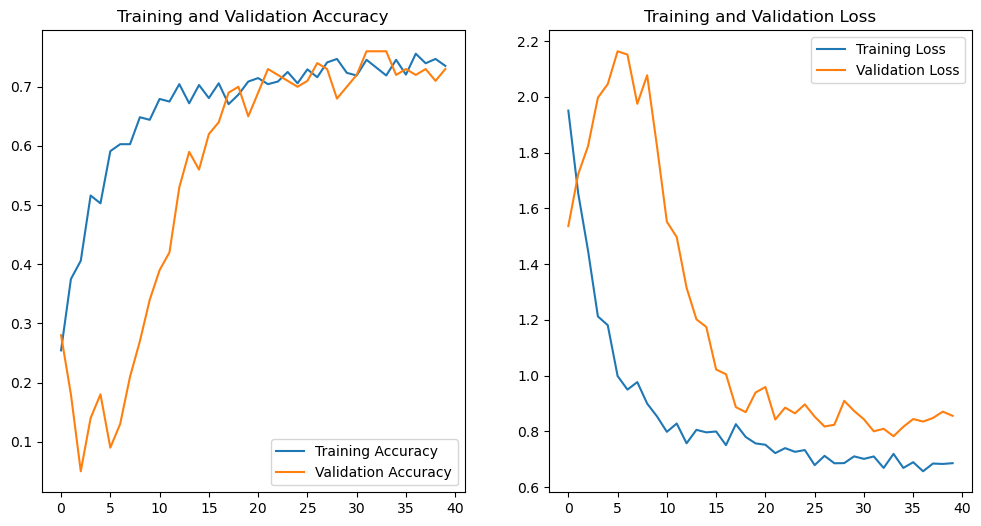

In [141]:
plot_training_validation_acc_loss(history9, num_epochs)

## Final Model

### Summary
By Looking into the above models we can see model-6 is providing highest training and validation accuracy.
Model-6 parameters are:
 - batch_size = 32
 - num_epochs = 40 
 - frame_nums = 20
 - img_idx = [0,2,4,6,8,10,11,12,13,14,15,16,17,18,19,20,22,24,26,28]
 - height = 120
 - width = 120

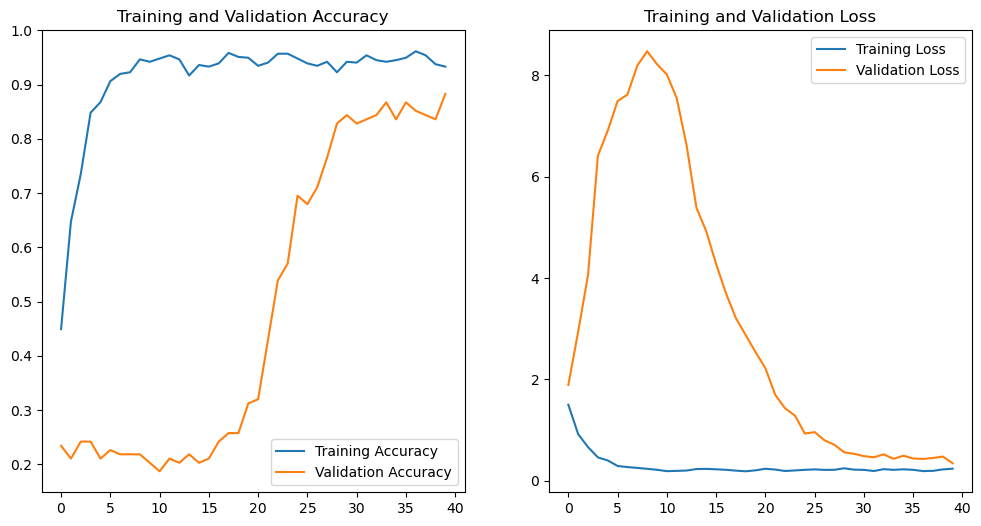

In [147]:
plot_training_validation_acc_loss(history6, num_epochs)

#### Training accuracy: 94%
#### Validation accuracy: 88% 

#### Model name: 
model-00040-0.23828-0.93304-0.34547-0.88281.weights.h5